# Kütüphanelerin Yüklenmesi ve Veriye Genel Bakış (Adım 1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Grafikler için genel tema ayarı
sns.set_theme(style="whitegrid")

In [ ]:
# Verileri yükleme
train_df = pd.read_csv('/content/drive/MyDrive/Datathon/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Datathon/test_x.csv')

print("--- TRAIN Veri Seti Boyutu ---")
print(f"Satır Sayısı: {train_df.shape[0]}, Sütun Sayısı: {train_df.shape[1]}\n")

print("--- TEST Veri Seti Boyutu ---")
print(f"Satır Sayısı: {test_df.shape[0]}, Sütun Sayısı: {test_df.shape[1]}\n")

print("--- TRAIN Veri Tipleri Özeti ---")
train_df.info()

print("\n--- TEST Veri Tipleri Özeti ---")
test_df.info()

print("\n--- TRAIN Veri Setinden İlk 5 Satır ---")
display(train_df.head())

--- TRAIN Veri Seti Boyutu ---
Satır Sayısı: 56000, Sütun Sayısı: 24

--- TEST Veri Seti Boyutu ---
Satır Sayısı: 24000, Sütun Sayısı: 23

--- TRAIN Veri Tipleri Özeti ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


#Train ve Test İçin Eksik Veri & Aykırı Değer (Outlier) Analizi (Adım 2)

In [ ]:
import math

--- TRAIN Veri Seti Eksiklikleri ---
                       Eksik Değer  Oran (%)
kronotip                      1968  3.514286
vucut_kitle_indeksi           1752  3.128571
stres_skoru                   1715  3.062500
uyku_oncesi_kafein_mg         1463  2.612500
meslek                        1378  2.460714
ruh_sagligi_durumu            1096  1.957143
----------------------------------------
--- TEST Veri Seti Eksiklikleri ---
                       Eksik Değer  Oran (%)
kronotip                       832  3.466667
stres_skoru                    765  3.187500
uyku_oncesi_kafein_mg          697  2.904167
vucut_kitle_indeksi            648  2.700000
meslek                         622  2.591667
ruh_sagligi_durumu             504  2.100000
----------------------------------------


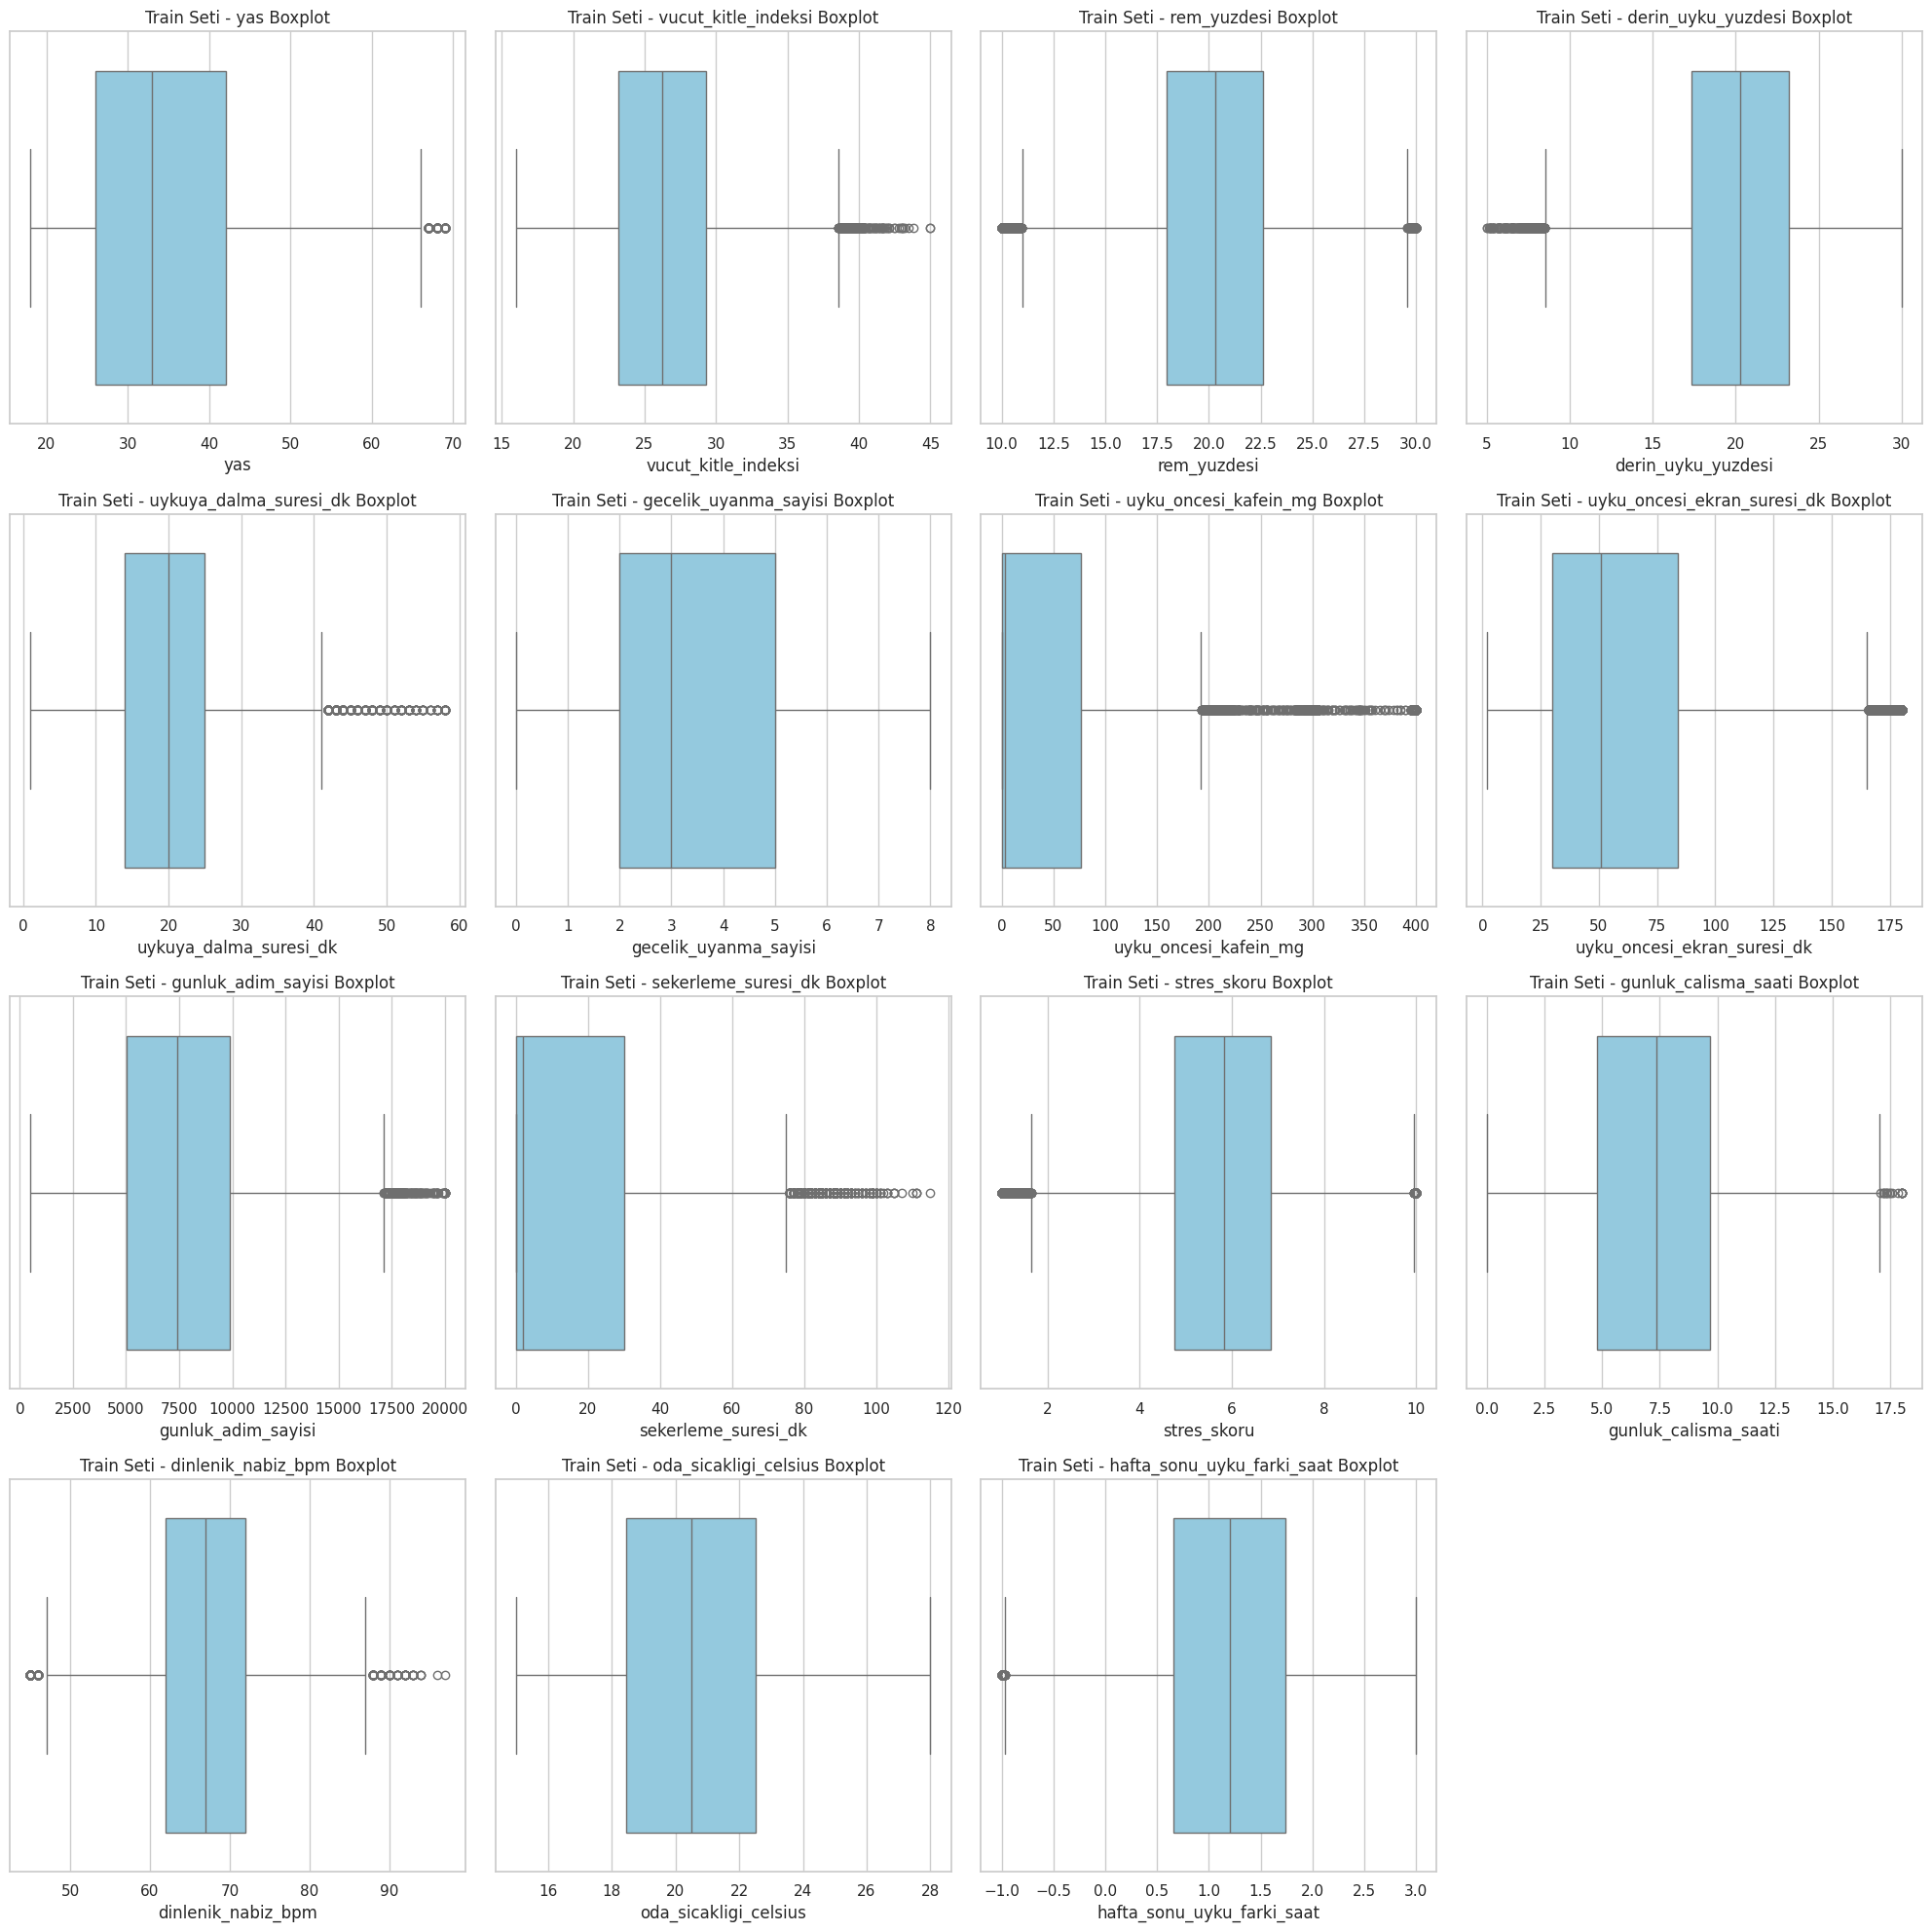

In [ ]:
def eksik_veri_analizi(df, isim):
    eksik = df.isnull().sum()
    oran = (eksik / len(df)) * 100
    tablo = pd.DataFrame({'Eksik Değer': eksik, 'Oran (%)': oran})
    tablo = tablo[tablo['Eksik Değer'] > 0].sort_values(by='Oran (%)', ascending=False)
    print(f"--- {isim} Veri Seti Eksiklikleri ---")
    print(tablo if not tablo.empty else "Eksik veri bulunmamaktadır.")
    print("-" * 40)

eksik_veri_analizi(train_df, "TRAIN")
eksik_veri_analizi(test_df, "TEST")

# Tüm sayısal değişkenleri (int ve float) otomatik seçelim
sayisal_degiskenler = train_df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# 'id' gibi outlier analizi mantıklı olmayan sütunları veya hedef değişkeni çıkaralım
dislanacak_sutunlar = ['id', 'bilissel_performans_skoru']
outlier_features = [col for col in sayisal_degiskenler if col not in dislanacak_sutunlar]

# Kaç adet sayısal değişken varsa grafikleri ona göre ölçeklendirelim
sutun_grafik_sayisi = 4
satir_sayisi = math.ceil(len(outlier_features) / sutun_grafik_sayisi)

if outlier_features:
    plt.figure(figsize=(20, 5 * satir_sayisi))
    for i, col in enumerate(outlier_features, 1):
        plt.subplot(satir_sayisi, sutun_grafik_sayisi, i)
        sns.boxplot(x=train_df[col], color='skyblue')
        plt.title(f'Train Seti - {col} Boxplot')
    plt.tight_layout()
    plt.show()

# Değişken Dağılımları (Train vs Test Karşılaştırması) (Adım 3)

--- Sayısal Değişken Dağılımları (Train vs Test) ---


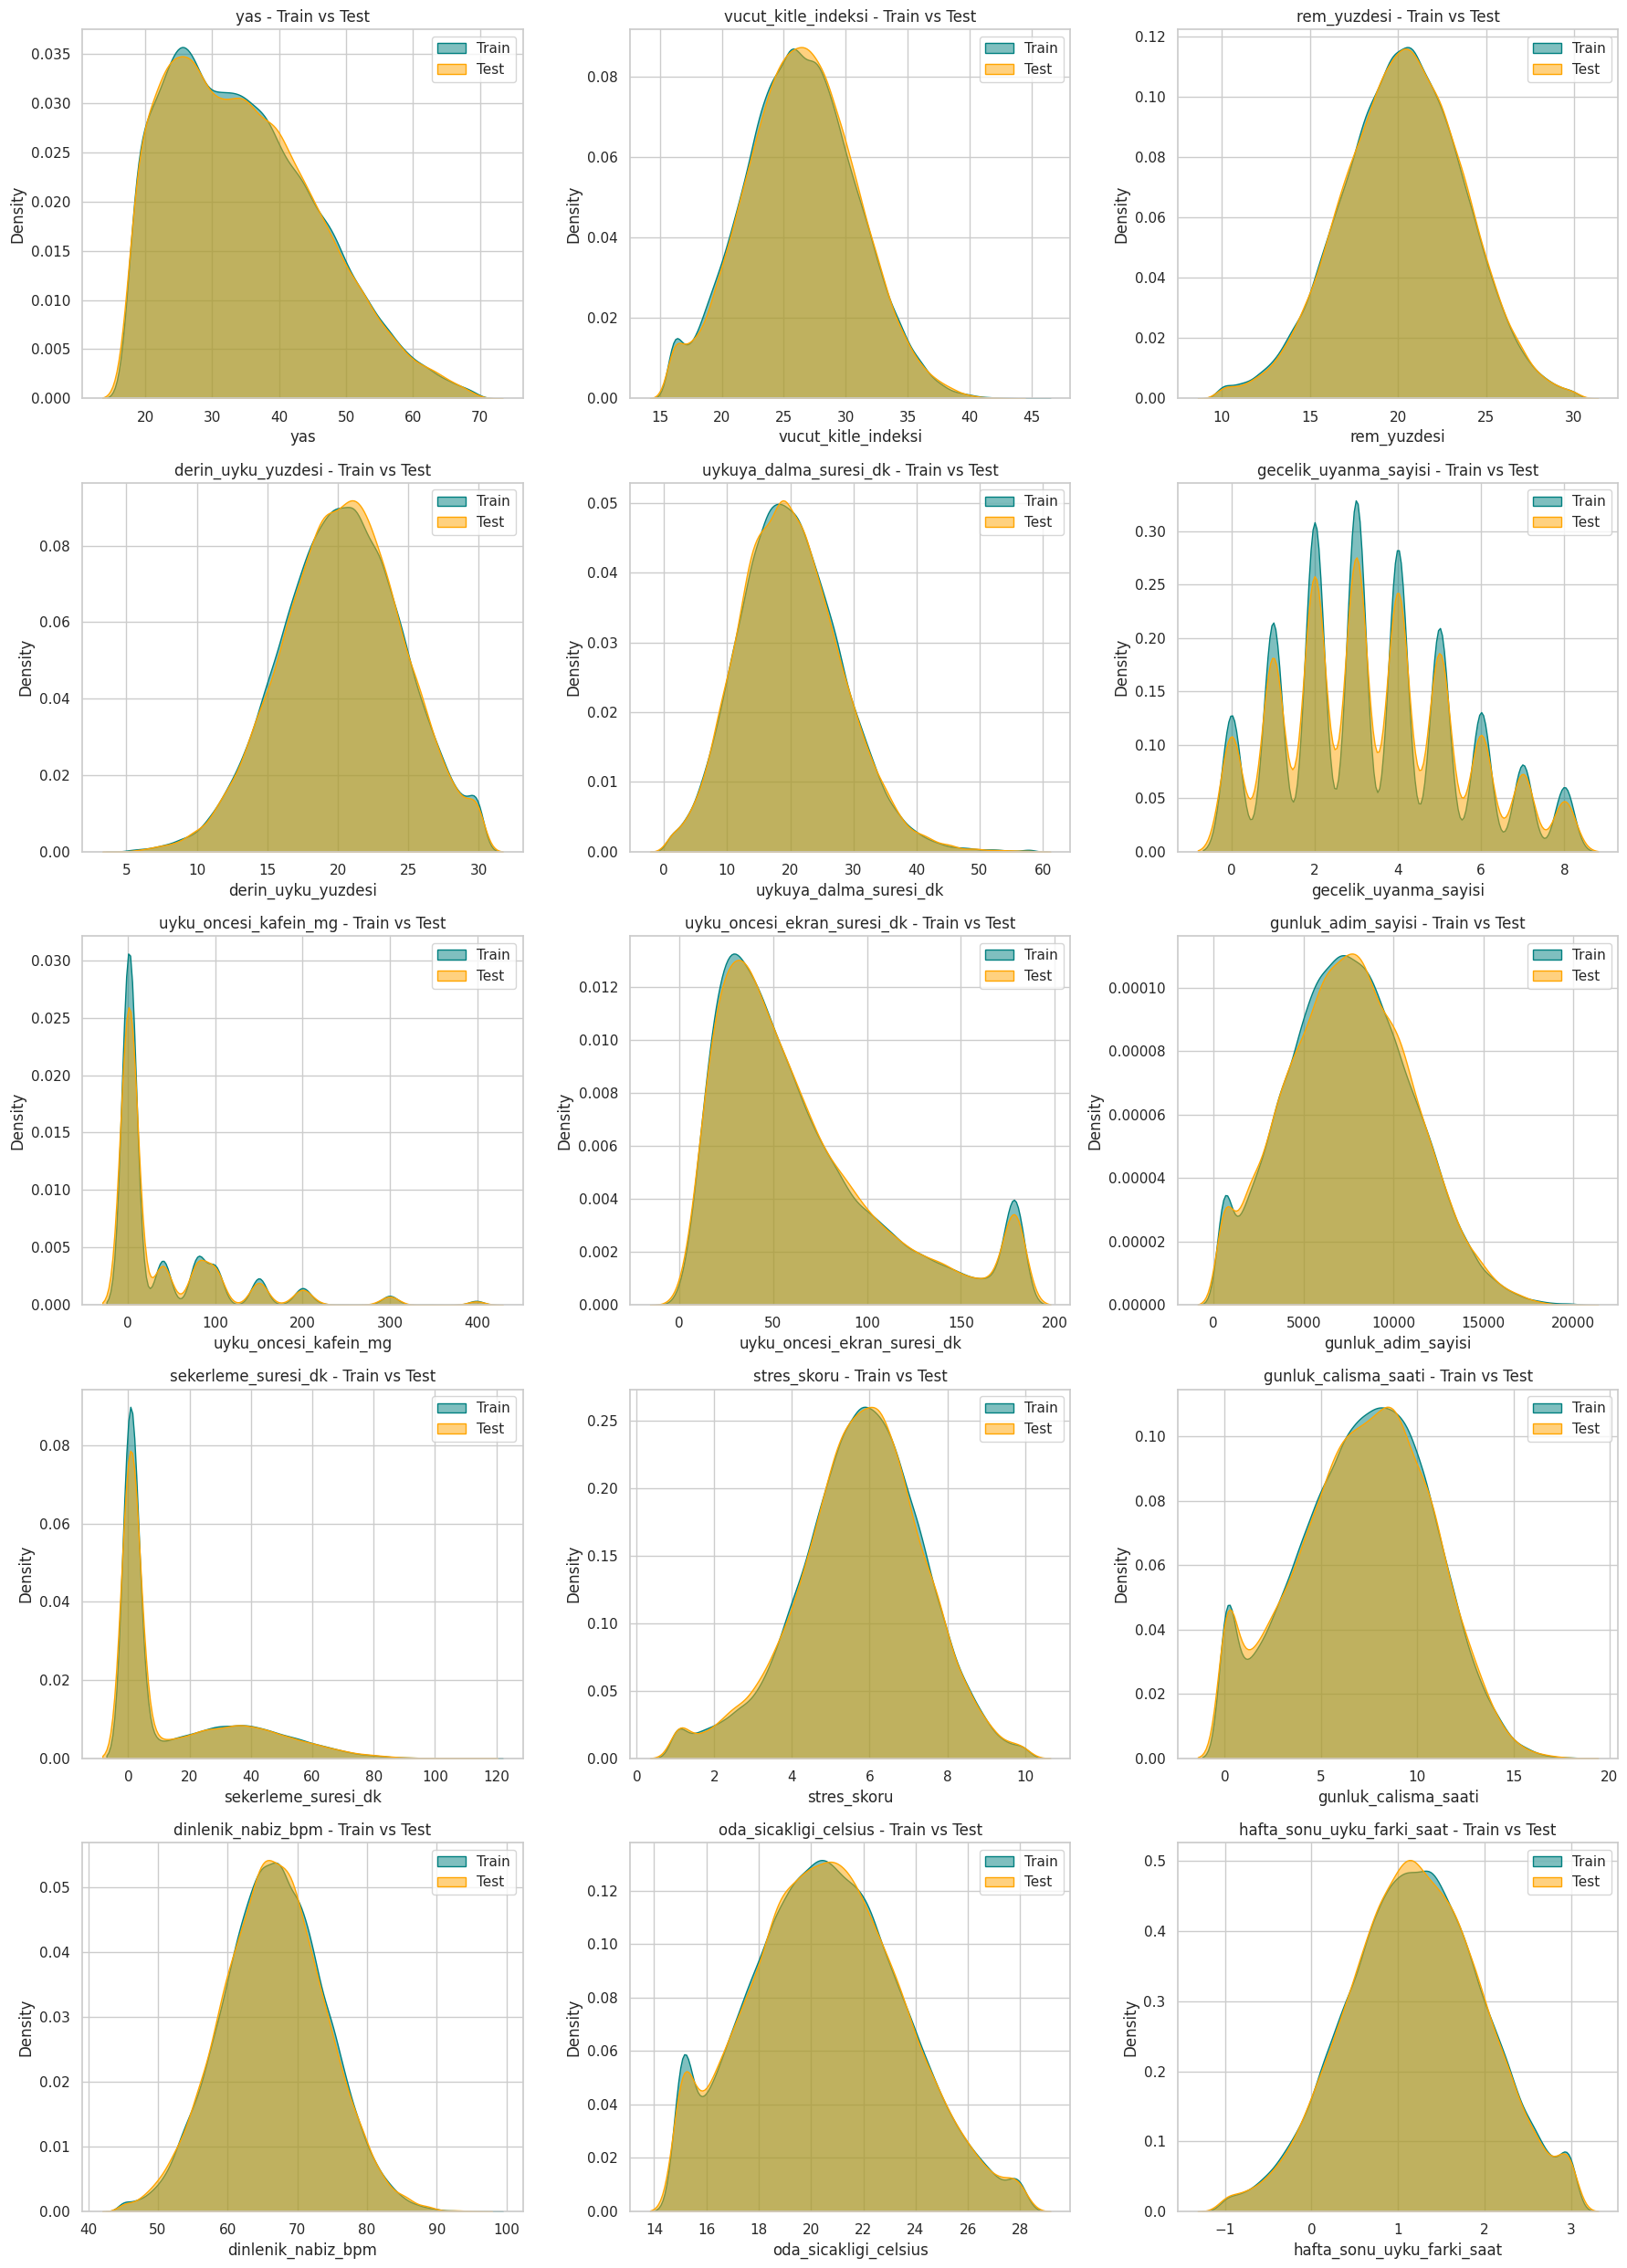


--- Kategorik Değişken Frekansları (Train vs Test) ---


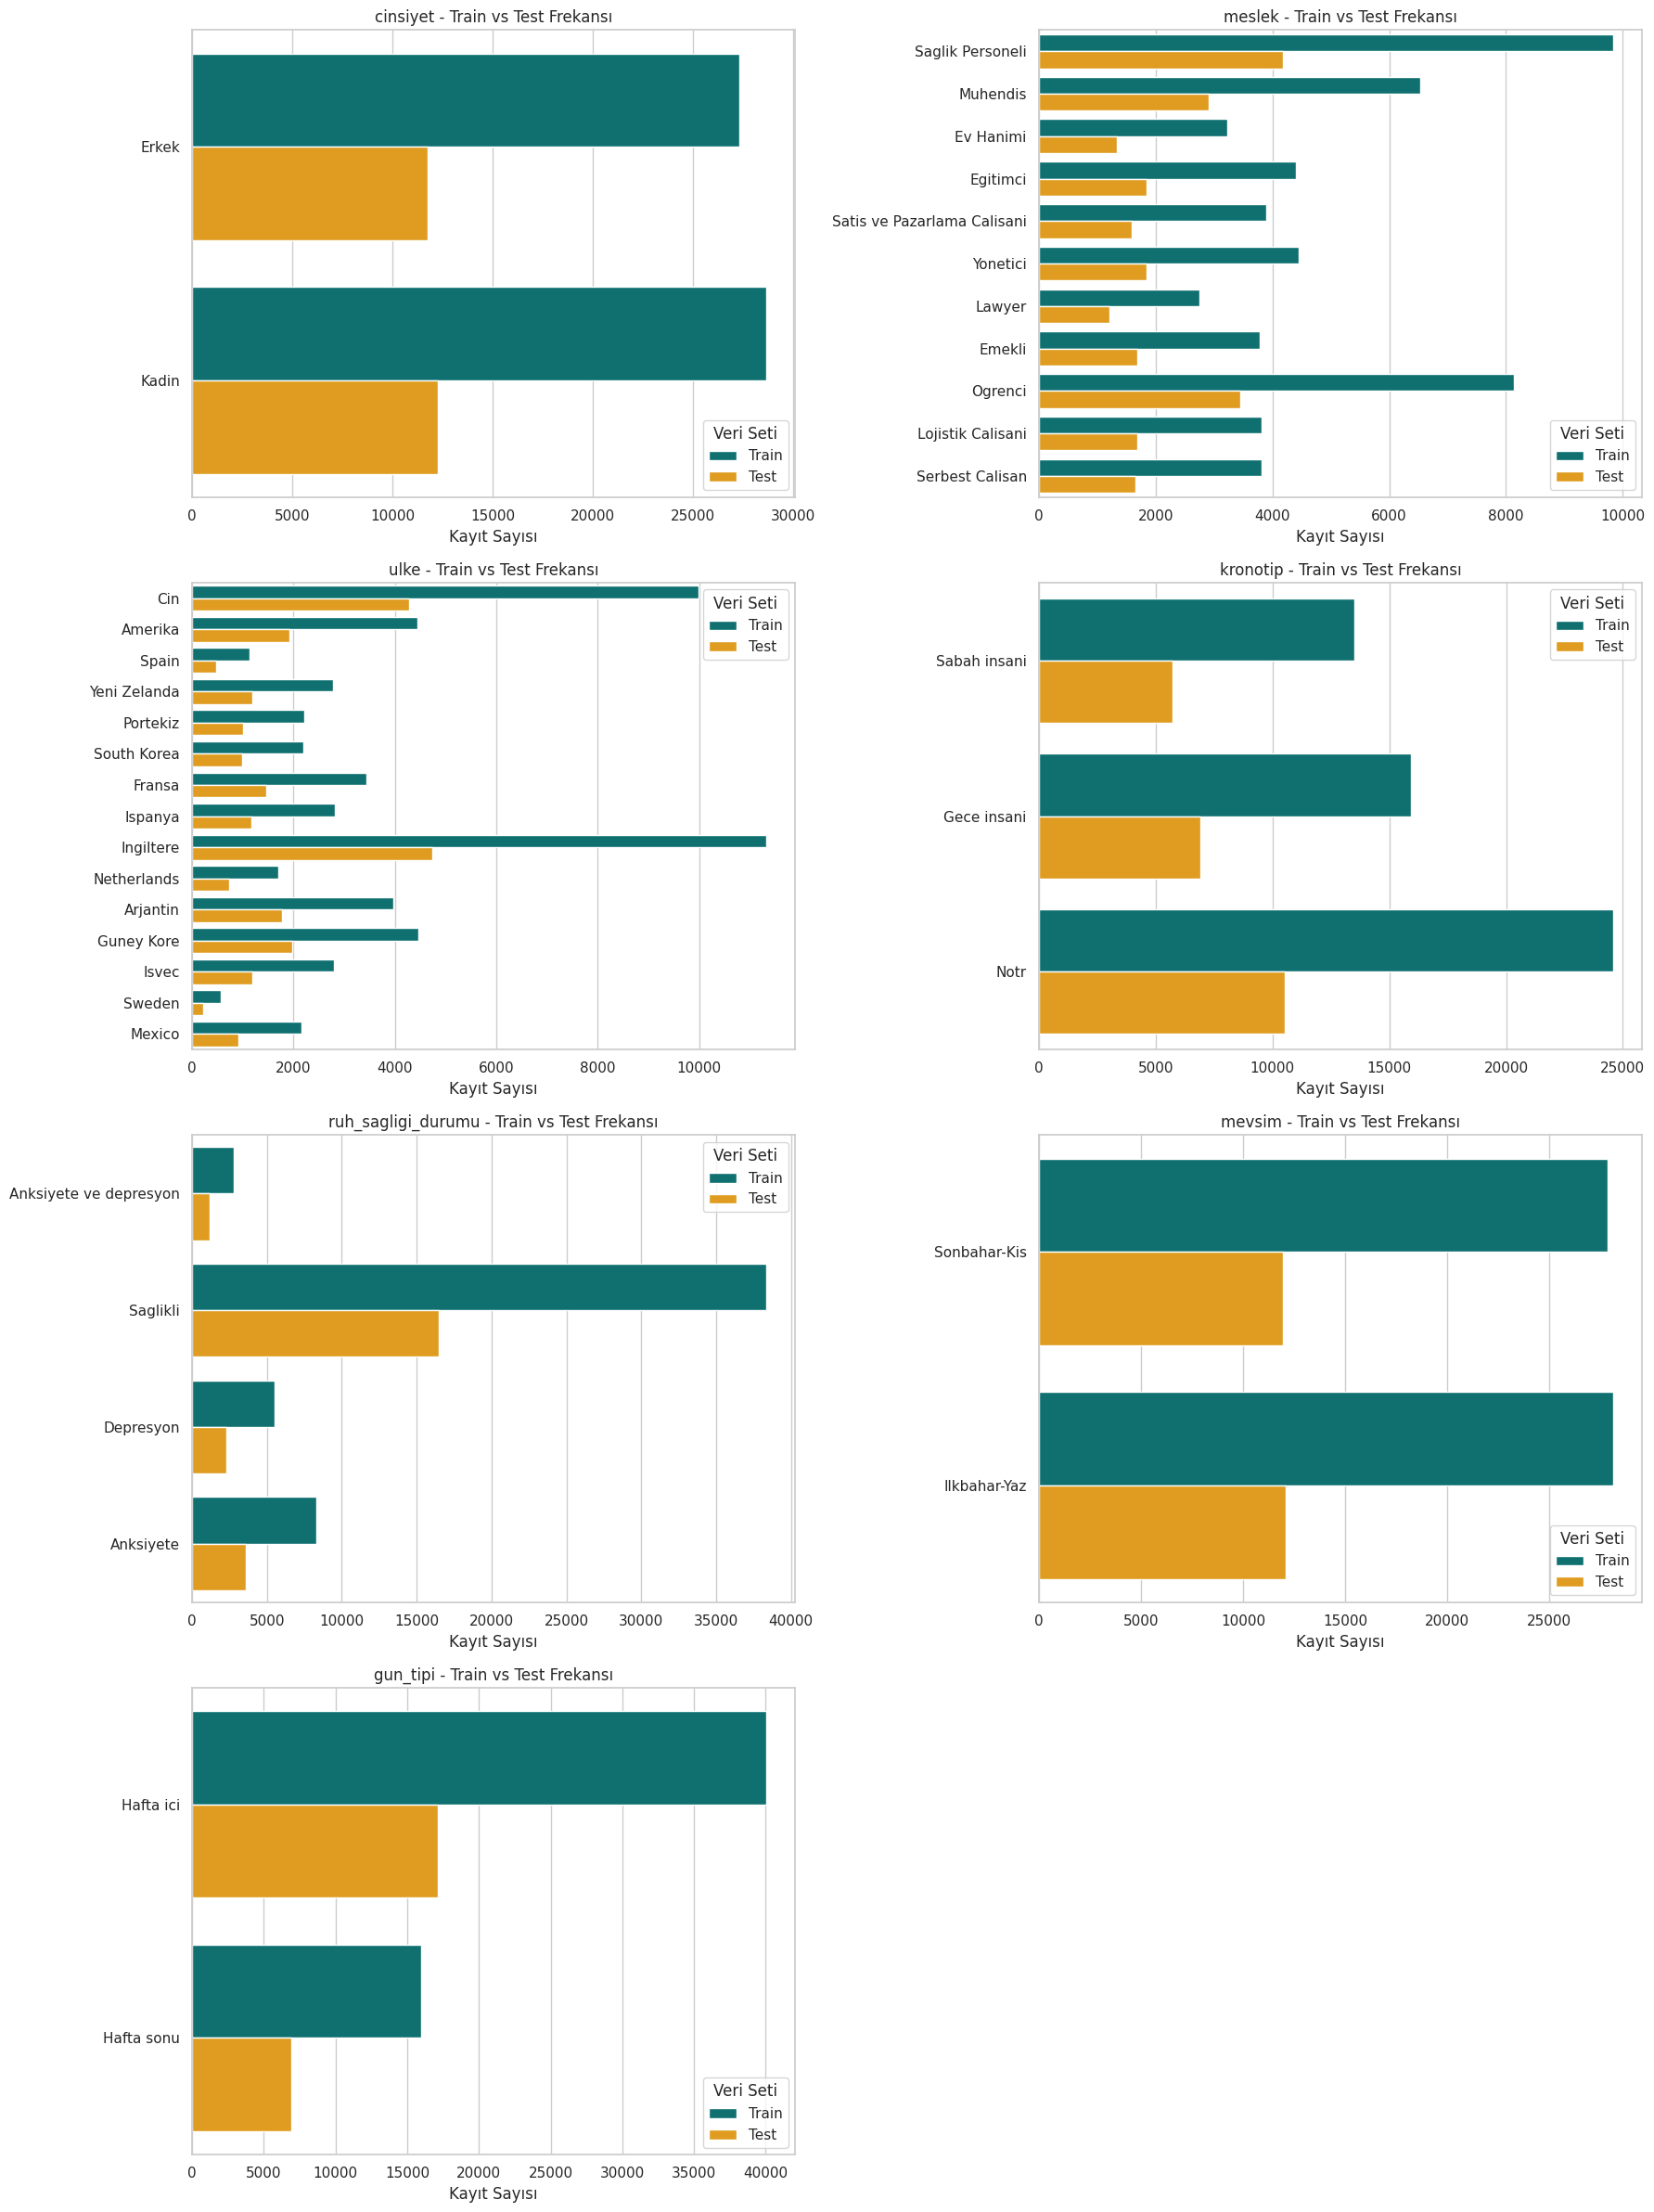

In [ ]:
# --- 1. SAYISAL DEĞİŞKENLERİN DAĞILIMI (Train vs Test) ---
print("--- Sayısal Değişken Dağılımları (Train vs Test) ---")

# Train setindeki tüm sayısal değişkenleri bul
num_cols = train_df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
dislanacak_sutunlar = ['id', 'bilissel_performans_skoru']

# Hem train hem test setinde olan ve dışlanmayan ortak sayısal özellikleri seç
num_features = [col for col in num_cols if col not in dislanacak_sutunlar and col in test_df.columns]

if num_features:
    sutun_sayisi = 3
    satir_sayisi = math.ceil(len(num_features) / sutun_sayisi)
    plt.figure(figsize=(18, 5 * satir_sayisi))

    for i, col in enumerate(num_features, 1):
        plt.subplot(satir_sayisi, sutun_sayisi, i)
        # Train ve Test yoğunluk grafiklerini (KDE) üst üste bindirme
        sns.kdeplot(train_df[col], label='Train', fill=True, color='teal', alpha=0.5)
        sns.kdeplot(test_df[col], label='Test', fill=True, color='orange', alpha=0.5)
        plt.title(f'{col} - Train vs Test')
        plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Karşılaştırılacak ortak sayısal değişken bulunamadı.")


# --- 2. KATEGORİK DEĞİŞKENLERİN FREKANSLARI (Train vs Test) ---
print("\n--- Kategorik Değişken Frekansları (Train vs Test) ---")

# Train setindeki tüm kategorik değişkenleri bul (object, category veya bool)
cat_cols = train_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Hem train hem test setinde olan ortak kategorik özellikleri seç
cat_features = [col for col in cat_cols if col not in dislanacak_sutunlar and col in test_df.columns]

if cat_features:
    # Karşılaştırmalı grafik çizebilmek için train ve test'i geçici bir dataframe'de birleştirelim
    temp_train = train_df[cat_features].copy()
    temp_train['Veri Seti'] = 'Train'

    temp_test = test_df[cat_features].copy()
    temp_test['Veri Seti'] = 'Test'

    # HATA ÇÖZÜMÜ BURADA: .reset_index(drop=True) ile indeksleri sıfırlıyoruz
    combined_cat = pd.concat([temp_train, temp_test], axis=0).reset_index(drop=True)

    sutun_sayisi = 2
    satir_sayisi = math.ceil(len(cat_features) / sutun_sayisi)
    plt.figure(figsize=(18, 6 * satir_sayisi))

    for i, col in enumerate(cat_features, 1):
        plt.subplot(satir_sayisi, sutun_sayisi, i)
        # Yan yana çubuk grafikleri çizdiriyoruz
        sns.countplot(data=combined_cat, y=col, hue='Veri Seti', palette={'Train': 'teal', 'Test': 'orange'})
        plt.title(f'{col} - Train vs Test Frekansı')
        plt.xlabel('Kayıt Sayısı')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()
else:
    print("Karşılaştırılacak ortak kategorik değişken bulunamadı.")

# Hedef Değişken Korelasyon ve Çift Değişkenli Analiz (Sadece Train)(Adım4)

--- 1. SAYISAL DEĞİŞKENLER İLE HEDEF DEĞİŞKEN KORELASYONU ---


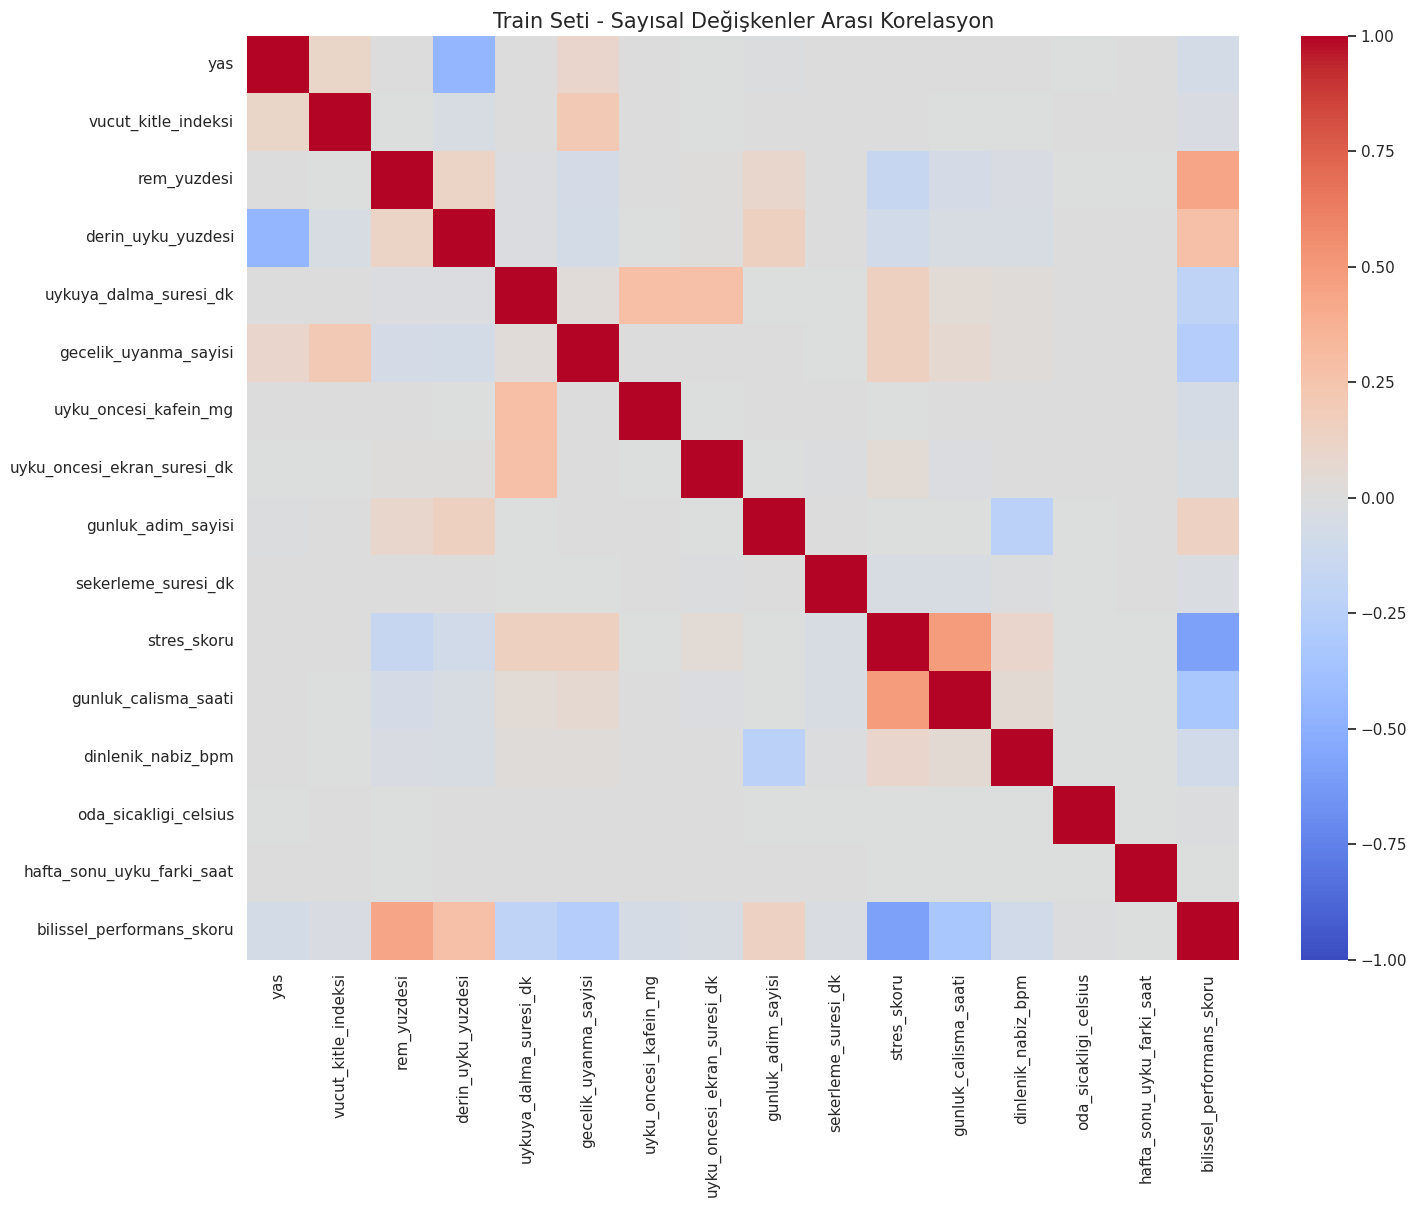


--- Hedefe En Çok Pozitif Etki Eden Özellikler ---
rem_yuzdesi                   0.442999
derin_uyku_yuzdesi            0.280006
gunluk_adim_sayisi            0.134042
hafta_sonu_uyku_farki_saat   -0.001648
oda_sicakligi_celsius        -0.011992
Name: bilissel_performans_skoru, dtype: float64

--- Hedefe En Çok Negatif Etki Eden (Ters Yönlü) Özellikler ---
stres_skoru              -0.586676
gunluk_calisma_saati     -0.342112
gecelik_uyanma_sayisi    -0.270349
uykuya_dalma_suresi_dk   -0.207349
dinlenik_nabiz_bpm       -0.089389
Name: bilissel_performans_skoru, dtype: float64

--- 2. KATEGORİK DEĞİŞKENLER BAZINDA HEDEF DEĞİŞKEN DAĞILIMI ---


/tmp/ipykernel_13314/631115573.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=hedef, data=train_df, palette='Set2')
/tmp/ipykernel_13314/631115573.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=hedef, data=train_df, palette='Set2')
/tmp/ipykernel_13314/631115573.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=hedef, data=train_df, palette='Set2')
/tmp/ipykernel_13314/631115573.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

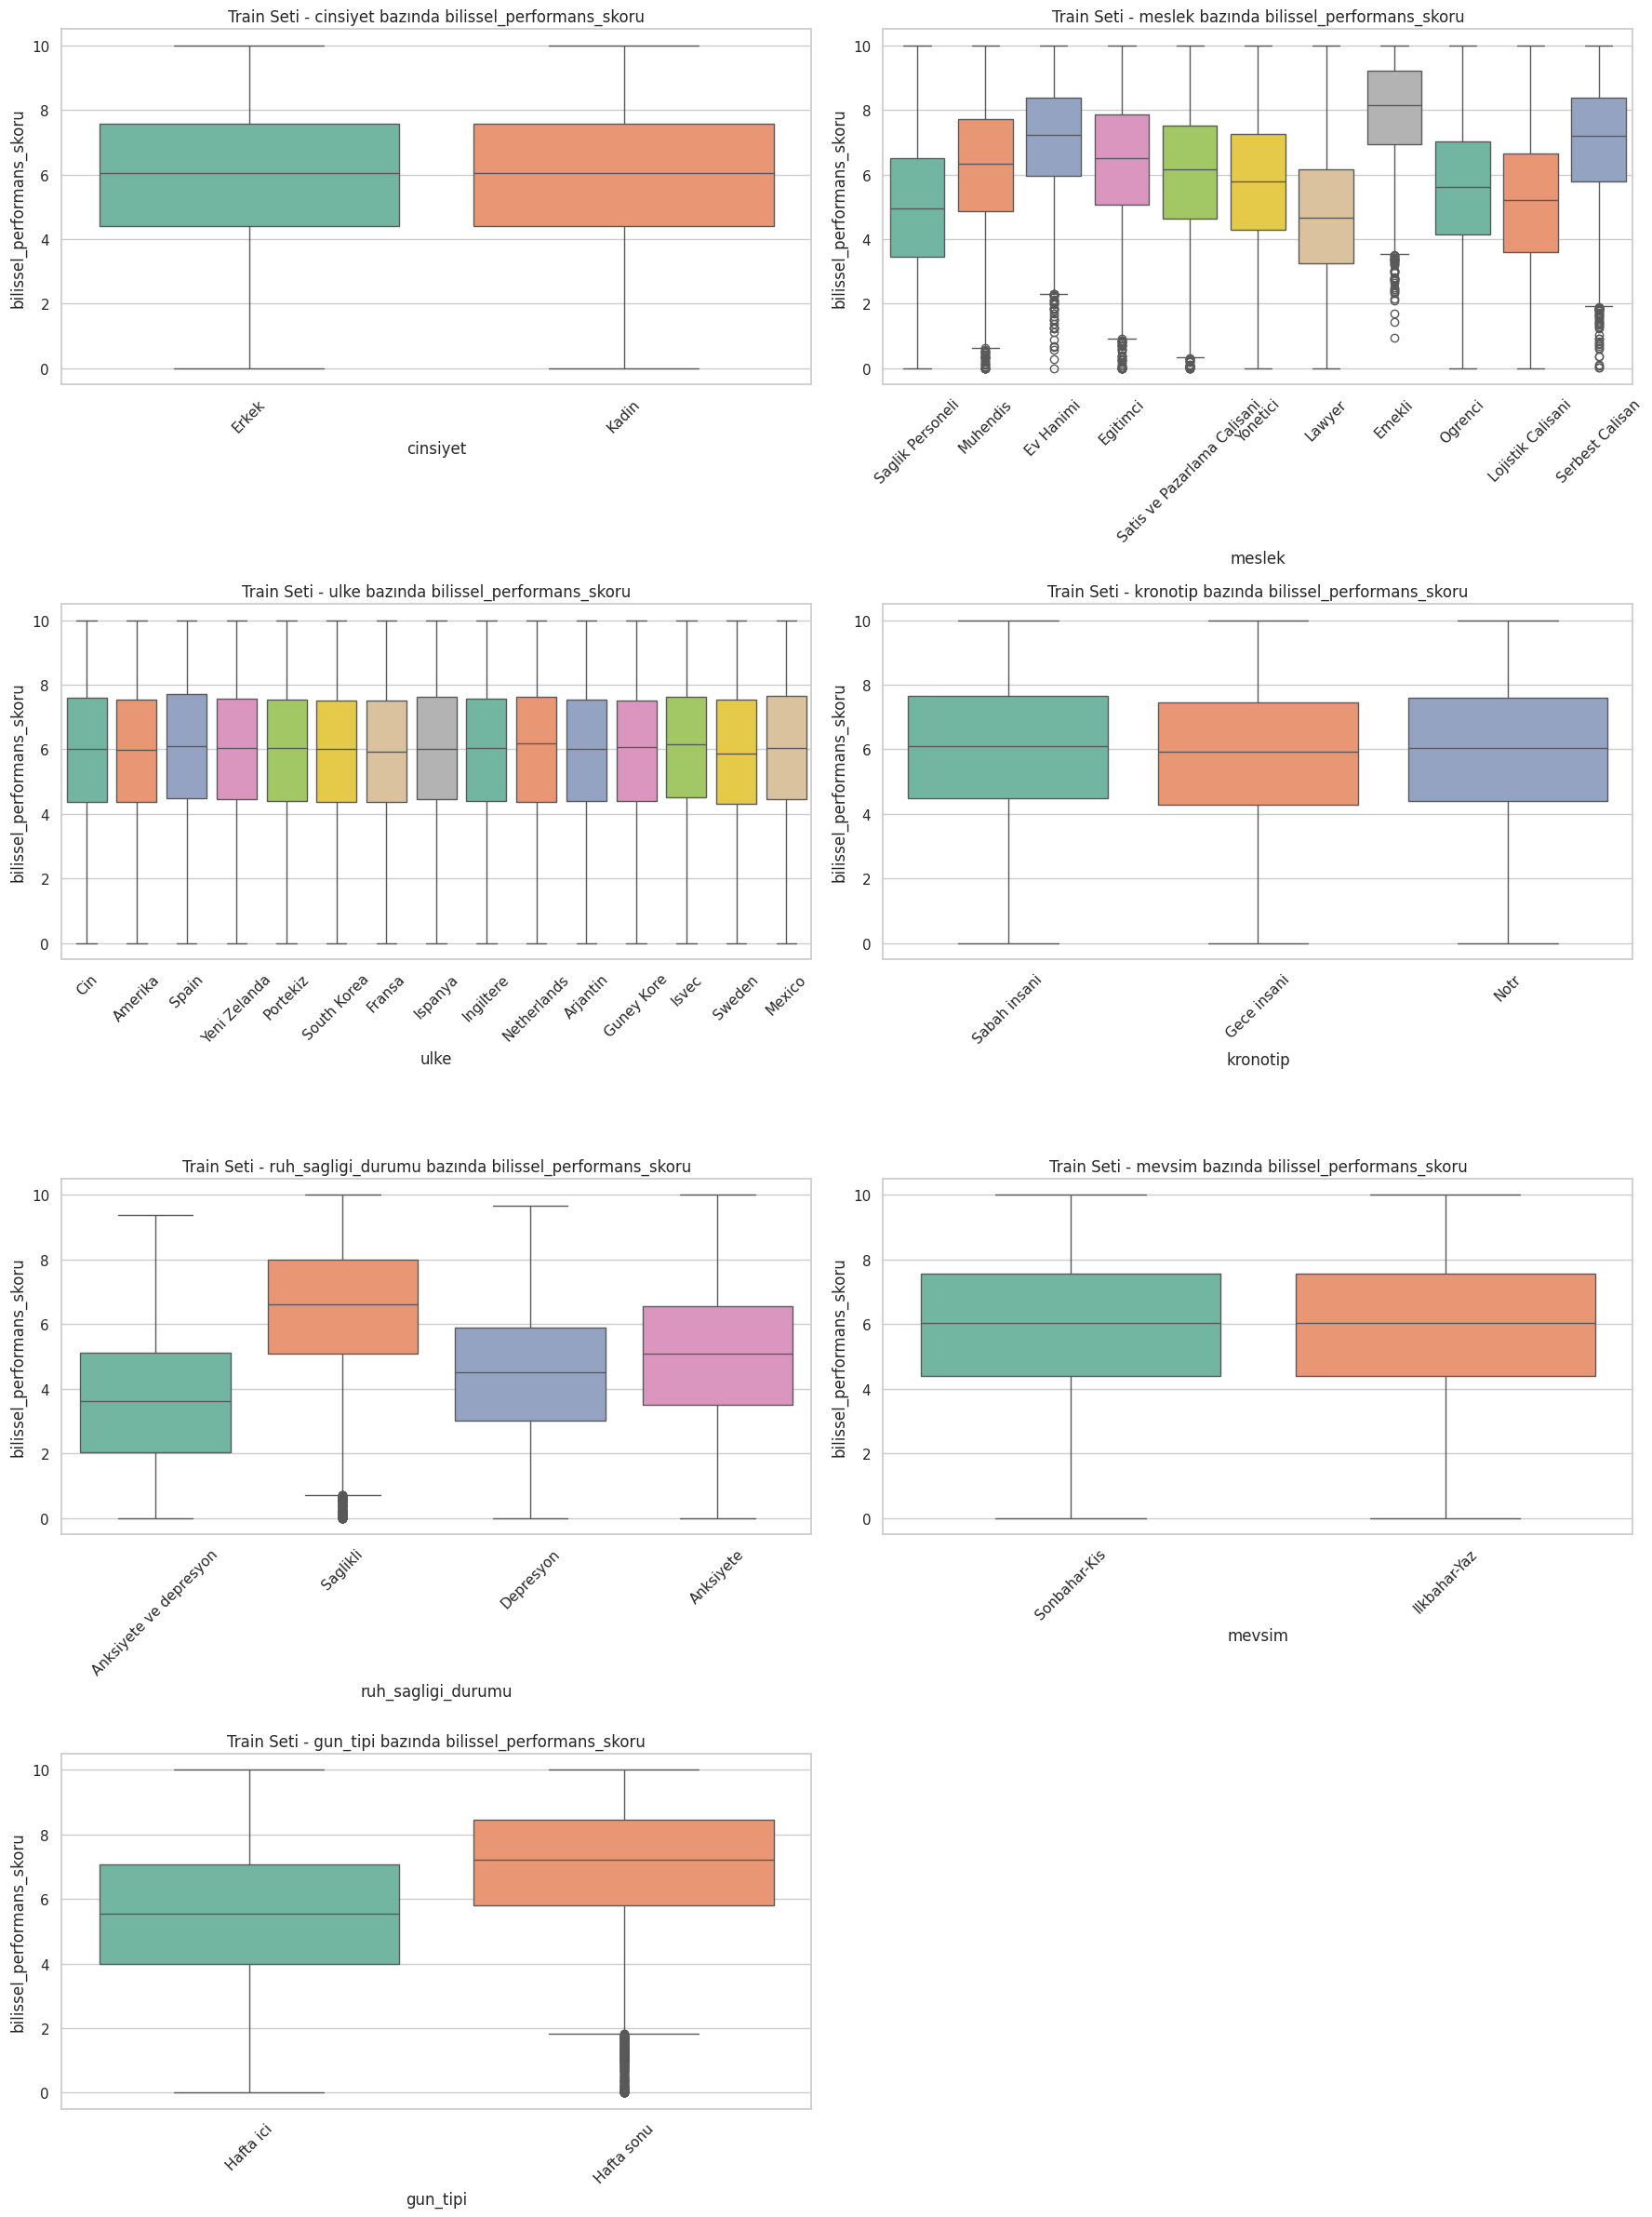

In [ ]:
hedef = 'bilissel_performans_skoru'

if hedef in train_df.columns:
    print("--- 1. SAYISAL DEĞİŞKENLER İLE HEDEF DEĞİŞKEN KORELASYONU ---")

    # Sadece sayısal değişkenleri seç ve id'yi dışla
    numeric_df = train_df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])
    if 'id' in numeric_df.columns:
        numeric_df = numeric_df.drop('id', axis=1)

    # Korelasyon matrisi
    plt.figure(figsize=(16, 12))
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Train Seti - Sayısal Değişkenler Arası Korelasyon', fontsize=15)
    plt.show()

    # Hedef değişken ile en çok ilişkiye sahip özellikler
    print("\n--- Hedefe En Çok Pozitif Etki Eden Özellikler ---")
    # Kendisiyle olan 1.0 korelasyonu atlamak için [1:] kullanıyoruz
    print(corr_matrix[hedef].sort_values(ascending=False).head(6)[1:])

    print("\n--- Hedefe En Çok Negatif Etki Eden (Ters Yönlü) Özellikler ---")
    print(corr_matrix[hedef].sort_values(ascending=True).head(5))

    print("\n--- 2. KATEGORİK DEĞİŞKENLER BAZINDA HEDEF DEĞİŞKEN DAĞILIMI ---")

    # Tüm kategorik değişkenleri bul (object, category, bool)
    cat_cols = train_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    dislanacak_sutunlar = ['id']
    cat_features = [col for col in cat_cols if col not in dislanacak_sutunlar]

    if cat_features:
        sutun_sayisi = 2
        satir_sayisi = math.ceil(len(cat_features) / sutun_sayisi)
        plt.figure(figsize=(18, 6 * satir_sayisi))

        for i, col in enumerate(cat_features, 1):
            plt.subplot(satir_sayisi, sutun_sayisi, i)
            # Kutu grafikleri (Boxplot) ile kategorik grupların performansa etkisini çizdiriyoruz
            sns.boxplot(x=col, y=hedef, data=train_df, palette='Set2')
            plt.title(f'Train Seti - {col} bazında {hedef}')
            plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()
    else:
        print("Kategorik değişken bulunamadı.")
else:
    print(f"Hedef değişken '{hedef}' veri setinde bulunamadı. Sütun ismini kontrol edin.")

# Feature Engineering

In [ ]:
def yeni_ozellikler_uret(df):
    # Veri setinin kopyasını alalım ki orijinal veriyi bozmayalım
    df_copy = df.copy()

    # 1. Kaliteli Uyku Oranı (Pozitif Etki Bekliyoruz)
    if 'rem_yuzdesi' in df_copy.columns and 'derin_uyku_yuzdesi' in df_copy.columns:
        df_copy['toplam_kaliteli_uyku_yuzdesi'] = df_copy['rem_yuzdesi'] + df_copy['derin_uyku_yuzdesi']

    # 2. Uyku Zorluğu Endeksi (Negatif Etki Bekliyoruz)
    if 'gecelik_uyanma_sayisi' in df_copy.columns and 'uykuya_dalma_suresi_dk' in df_copy.columns:
        df_copy['uyku_zorlugu_endeksi'] = df_copy['gecelik_uyanma_sayisi'] * df_copy['uykuya_dalma_suresi_dk']

    # 3. Zihinsel Yük Endeksi (Negatif Etki Bekliyoruz)
    if 'stres_skoru' in df_copy.columns and 'gunluk_calisma_saati' in df_copy.columns:
        df_copy['zihinsel_yuk_endeksi'] = df_copy['stres_skoru'] * df_copy['gunluk_calisma_saati']

    # 4. Uyku Hijyeni Bozucu Skoru (Negatif Etki Bekliyoruz)
    if 'uyku_oncesi_kafein_mg' in df_copy.columns and 'uyku_oncesi_ekran_suresi_dk' in df_copy.columns:
        # Kafein mg cinsinden (örn: 200mg), ekran süresi dk (örn: 60dk).
        # Sayısal ağırlıkları dengelemek için kafeini 10'a bölüp ekliyoruz.
        df_copy['uyku_hijyeni_bozucu'] = df_copy['uyku_oncesi_ekran_suresi_dk'] + (df_copy['uyku_oncesi_kafein_mg'] / 10)

    return df_copy

# Fonksiyonu hem Train hem de Test setine uyguluyoruz
train_df = yeni_ozellikler_uret(train_df)
test_df = yeni_ozellikler_uret(test_df)

print("--- Yeni Özellikler Başarıyla Üretildi! ---")
# Yeni sütunlardan birkaçını kontrol edelim
display(train_df[['toplam_kaliteli_uyku_yuzdesi', 'uyku_zorlugu_endeksi', 'zihinsel_yuk_endeksi', 'uyku_hijyeni_bozucu']].head())

# Yeni oluşturduğumuz sütunların Hedef Değişken ile korelasyonuna bakalım
yeni_sutunlar = ['toplam_kaliteli_uyku_yuzdesi', 'uyku_zorlugu_endeksi', 'zihinsel_yuk_endeksi', 'uyku_hijyeni_bozucu', 'bilissel_performans_skoru']
if all(col in train_df.columns for col in yeni_sutunlar):
    print("\n--- Yeni Özelliklerin Hedef Değişkenle Korelasyonu ---")
    print(train_df[yeni_sutunlar].corr()['bilissel_performans_skoru'].sort_values(ascending=False))

--- Yeni Özellikler Başarıyla Üretildi! ---


,toplam_kaliteli_uyku_yuzdesi,uyku_zorlugu_endeksi,zihinsel_yuk_endeksi,uyku_hijyeni_bozucu
0,29.076646,189,99.679011,97.0
1,48.992230,80,41.873844,180.4
2,43.708961,231,23.304616,37.8
3,37.329339,42,14.565145,180.0
4,41.824756,168,22.957118,155.0



--- Yeni Özelliklerin Hedef Değişkenle Korelasyonu ---
bilissel_performans_skoru       1.000000
toplam_kaliteli_uyku_yuzdesi    0.469163
uyku_hijyeni_bozucu            -0.055040
uyku_zorlugu_endeksi           -0.318641
zihinsel_yuk_endeksi           -0.488610
Name: bilissel_performans_skoru, dtype: float64


In [ ]:
def ileri_seviye_ozellikler_uret(df):
    df_copy = df.copy()

    # 1. Sosyal Jetlag (Mutlak Uyku Düzensizliği)
    if 'hafta_sonu_uyku_farki_saat' in df_copy.columns:
        df_copy['sosyal_jetlag_mutlak'] = df_copy['hafta_sonu_uyku_farki_saat'].abs()

    # 2. Fiziksel Dinçlik Oranı (Adım / Nabız)
    if 'gunluk_adim_sayisi' in df_copy.columns and 'dinlenik_nabiz_bpm' in df_copy.columns:
        # Nabzın 0 olma ihtimaline karşı (veri hatası vb.) paydaya küçük bir epsilon (0.1) ekliyoruz
        df_copy['fiziksel_dinclik_orani'] = df_copy['gunluk_adim_sayisi'] / (df_copy['dinlenik_nabiz_bpm'] + 0.1)

    # 3. İdeal Sıcaklıktan Sapma (Optimum 20 derece varsayımıyla)
    if 'oda_sicakligi_celsius' in df_copy.columns:
        df_copy['sicaklik_sapmasi_20C'] = (df_copy['oda_sicakligi_celsius'] - 20).abs()

    # 4. Gece Uyanmasını Şekerleme ile Telafi Skoru
    if 'sekerleme_suresi_dk' in df_copy.columns and 'gecelik_uyanma_sayisi' in df_copy.columns:
        # Hiç uyanmayanlar (0) için bölme hatası almamak adına paydaya 1 ekliyoruz
        df_copy['sekerleme_telafi_skoru'] = df_copy['sekerleme_suresi_dk'] / (df_copy['gecelik_uyanma_sayisi'] + 1)

    return df_copy

# Fonksiyonu hem Train hem de Test setine uyguluyoruz
train_df = ileri_seviye_ozellikler_uret(train_df)
test_df = ileri_seviye_ozellikler_uret(test_df)

print("--- İleri Seviye Özellikler Başarıyla Üretildi! ---")

# Yeni oluşturduğumuz sütunların Hedef Değişken ile korelasyonuna bakalım
ileri_sutunlar = ['sosyal_jetlag_mutlak', 'fiziksel_dinclik_orani', 'sicaklik_sapmasi_20C', 'sekerleme_telafi_skoru', 'bilissel_performans_skoru']

if all(col in train_df.columns for col in ileri_sutunlar):
    print("\n--- Yeni Özelliklerin Hedef Değişkenle Korelasyonu ---")
    print(train_df[ileri_sutunlar].corr()['bilissel_performans_skoru'].sort_values(ascending=False))

--- İleri Seviye Özellikler Başarıyla Üretildi! ---

--- Yeni Özelliklerin Hedef Değişkenle Korelasyonu ---
bilissel_performans_skoru    1.000000
fiziksel_dinclik_orani       0.142631
sekerleme_telafi_skoru       0.066813
sosyal_jetlag_mutlak        -0.002252
sicaklik_sapmasi_20C        -0.044974
Name: bilissel_performans_skoru, dtype: float64


**Sayısal Sütunlarımız:**

* toplam_kaliteli_uyku_yuzdesi

* zihinsel_yuk_endeksi

* uyku_zorlugu_endeksi

* fiziksel_dinclik_orani

**Kategorik Sütunlarımız:**

* meslek

* ruh_sagligi_durumu

* gun_tipi

# Eksik Veri Doldurma

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
# 1. ALTIN KADROYU OLUŞTURMA VE FİLTRELEME
def altin_kadro_hazirla(df):
    df_copy = df.copy()

    # Türetilmiş özellikleri hesapla (Eğer daha önce oluşturmadıysak diye garantiye alıyoruz)
    df_copy['toplam_kaliteli_uyku_yuzdesi'] = df_copy['rem_yuzdesi'] + df_copy['derin_uyku_yuzdesi']
    df_copy['zihinsel_yuk_endeksi'] = df_copy['stres_skoru'] * df_copy['gunluk_calisma_saati']
    df_copy['uyku_zorlugu_endeksi'] = df_copy['gecelik_uyanma_sayisi'] * df_copy['uykuya_dalma_suresi_dk']
    df_copy['fiziksel_dinclik_orani'] = df_copy['gunluk_adim_sayisi'] / (df_copy['dinlenik_nabiz_bpm'] + 0.1)

    # Sadece Altın Kadro sütunlarını seç
    secilecek_sutunlar = [
        'toplam_kaliteli_uyku_yuzdesi', 'zihinsel_yuk_endeksi',
        'uyku_zorlugu_endeksi', 'fiziksel_dinclik_orani',
        'meslek', 'ruh_sagligi_durumu', 'gun_tipi'
    ]

    # Eğer dataframe'de hedef değişkenimiz varsa (Train seti) onu da kaybetmemek için ekle
    if 'bilissel_performans_skoru' in df_copy.columns:
        secilecek_sutunlar.append('bilissel_performans_skoru')

    return df_copy[secilecek_sutunlar]

# Fonksiyonu her iki sete de uygula
train_altin = altin_kadro_hazirla(train_df)
test_altin = altin_kadro_hazirla(test_df)


# 2. EKSİK VERİ DOLDURMA (IMPUTATION)
print("--- Eksik Veriler Dolduruluyor ---")

sayisal_sutunlar = ['toplam_kaliteli_uyku_yuzdesi', 'zihinsel_yuk_endeksi', 'uyku_zorlugu_endeksi', 'fiziksel_dinclik_orani']
kategorik_sutunlar = ['meslek', 'ruh_sagligi_durumu', 'gun_tipi']

# Sayısal için Medyan, Kategorik için Mod Imputer'larını hazırlayalım
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# DİKKAT: Imputer'ları SADECE Train setine fit ediyoruz!
# Sayısal verileri doldurma
train_altin[sayisal_sutunlar] = num_imputer.fit_transform(train_altin[sayisal_sutunlar])
test_altin[sayisal_sutunlar] = num_imputer.transform(test_altin[sayisal_sutunlar])

# Kategorik verileri doldurma
train_altin[kategorik_sutunlar] = cat_imputer.fit_transform(train_altin[kategorik_sutunlar])
test_altin[kategorik_sutunlar] = cat_imputer.transform(test_altin[kategorik_sutunlar])

print("✅ Eksik veriler başarıyla Medyan ve Mod yöntemleriyle dolduruldu!\n")
print("--- Train Seti Son Eksiklik Durumu ---")
print(train_altin.isnull().sum())

--- Eksik Veriler Dolduruluyor ---
✅ Eksik veriler başarıyla Medyan ve Mod yöntemleriyle dolduruldu!

--- Train Seti Son Eksiklik Durumu ---
toplam_kaliteli_uyku_yuzdesi    0
zihinsel_yuk_endeksi            0
uyku_zorlugu_endeksi            0
fiziksel_dinclik_orani          0
meslek                          0
ruh_sagligi_durumu              0
gun_tipi                        0
bilissel_performans_skoru       0
dtype: int64


# Encoding & Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
# 1. KATEGORİK DEĞİŞKENLERİ KODLAMA (One-Hot Encoding)
print("--- Kategorik Değişkenler Kodlanıyor ---")
kategorik_sutunlar = ['meslek', 'ruh_sagligi_durumu', 'gun_tipi']

# get_dummies ile dönüştürme (drop_first=True ile dummy variable trap'i önlüyoruz)
train_encoded = pd.get_dummies(train_altin, columns=kategorik_sutunlar, drop_first=True)
test_encoded = pd.get_dummies(test_altin, columns=kategorik_sutunlar, drop_first=True)

# Train ve Test setlerindeki sütunları eşitleme (Hizalama - Alignment)
# Hedef değişkeni geçici olarak ayırıp hizalama yapmalıyız ki test setine hedef değişken eklenmesin
y_train = train_encoded['bilissel_performans_skoru']
X_train = train_encoded.drop('bilissel_performans_skoru', axis=1)
X_test = test_encoded.copy()

# join='left' ile Train setindeki sütun yapısını baz alıyoruz, olmayanları 0 ile dolduruyoruz
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


# 2. SAYISAL DEĞİŞKENLERİ ÖLÇEKLENDİRME (Robust Scaling)
print("--- Sayısal Değişkenler Ölçeklendiriliyor ---")
sayisal_sutunlar = ['toplam_kaliteli_uyku_yuzdesi', 'zihinsel_yuk_endeksi', 'uyku_zorlugu_endeksi', 'fiziksel_dinclik_orani']

scaler = RobustScaler()

# Sadece sayısal sütunları ölçeklendiriyoruz
# Fit işlemi SADECE Train setinde yapılır (Veri sızıntısını önlemek için)
X_train[sayisal_sutunlar] = scaler.fit_transform(X_train[sayisal_sutunlar])
X_test[sayisal_sutunlar] = scaler.transform(X_test[sayisal_sutunlar])

print("✅ Encoding ve Scaling işlemleri başarıyla tamamlandı!\n")
print(f"Eğitim (Train) Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

--- Kategorik Değişkenler Kodlanıyor ---
--- Sayısal Değişkenler Ölçeklendiriliyor ---
✅ Encoding ve Scaling işlemleri başarıyla tamamlandı!

Eğitim (Train) Seti Boyutu: (56000, 18)
Test Seti Boyutu: (24000, 18)


# 6. Adım: Model Kurulumu ve Değerlendirme (RMSE)

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Modeller
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
# 1. Hiperparametre Arama Uzayları (Grid)
param_grids = {
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    },
    "LightGBM": {
        'n_estimators': [100, 200, 500],
        'max_depth': [-1, 5, 10, 15],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'num_leaves': [31, 50, 100],
        'subsample': [0.6, 0.8, 1.0]
    }
}

# 2. Temel Modeller
base_models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

print("--- Hiperparametre Optimizasyonu Başlıyor (Bu işlem biraz sürebilir) ---\n")

en_iyi_modeller = {}
optimizasyon_sonuclari = {}

# 3. Optimizasyon Döngüsü
for isim, model in base_models.items():
    print(f"⏳ {isim} optimize ediliyor...")

    # RandomizedSearchCV Ayarları
    # n_iter=15: Her model için 15 farklı kombinasyon denenecek (Süreyi kısaltmak için ideal)
    # cv=3: 3 Katlamalı Çapraz Doğrulama (Cross-Validation)
    # scoring: Hedefimiz RMSE'yi düşürmek
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[isim],
        n_iter=15,
        cv=3,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1 # Colab'deki tüm işlemcileri kullan
    )

    # Optimizasyonu başlat (Sadece Eğitim seti üzerinde çalışır)
    random_search.fit(X_tr, y_tr)

    # En iyi modeli kaydet
    best_model = random_search.best_estimator_
    en_iyi_modeller[isim] = best_model

    # Doğrulama (Validation) seti ile test et
    y_pred_val = best_model.predict(X_val)
    best_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    best_r2 = r2_score(y_val, y_pred_val)

    optimizasyon_sonuclari[isim] = {'RMSE': best_rmse, 'R2': best_r2}

    print(f"✅ {isim} Tamamlandı!")
    print(f"   Bulunan En İyi Parametreler: {random_search.best_params_}")
    print(f"   Yeni Validation RMSE : {best_rmse:.4f}")
    print(f"   Yeni Validation R²   : {best_r2:.4f}\n")

# Genel Kazananı Belirleme
sampiyon_isim = min(optimizasyon_sonuclari, key=lambda k: optimizasyon_sonuclari[k]['RMSE'])
sampiyon_model = en_iyi_modeller[sampiyon_isim]

print("*" * 50)
print(f"🏆 GÜNÜN ŞAMPİYONU: {sampiyon_isim}")
print(f"🏅 Şampiyonun RMSE Skoru: {optimizasyon_sonuclari[sampiyon_isim]['RMSE']:.4f}")
print("*" * 50)

--- Hiperparametre Optimizasyonu Başlıyor (Bu işlem biraz sürebilir) ---

⏳ Random Forest optimize ediliyor...
✅ Random Forest Tamamlandı!
   Bulunan En İyi Parametreler: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
   Yeni Validation RMSE : 1.3806
   Yeni Validation R²   : 0.6204

⏳ XGBoost optimize ediliyor...
✅ XGBoost Tamamlandı!
   Bulunan En İyi Parametreler: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
   Yeni Validation RMSE : 1.3503
   Yeni Validation R²   : 0.6369

⏳ LightGBM optimize ediliyor...
✅ LightGBM Tamamlandı!
   Bulunan En İyi Parametreler: {'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
   Yeni Validation RMSE : 1.3530
   Yeni Validation R²   : 0.6354

**************************************************
🏆 GÜNÜN ŞAMPİYONU: XGBoost
🏅 Şampiyonun RMSE Skoru: 1.3503
**************************************************
